***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.8 宽带与宽场高级成像](9_8_wideband_and_widefield_imaging.ipynb)
    * 下一节： [9.10 短间距、单碟与联合成像](9_10_short_spacing_and_feather.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.9 偏振成像与 RM 入门：Stokes 成像、偏振偏差与 leakage

偏振数据处理通常是很多初学者第一次真正意识到“干涉成像不只是在做 Stokes I 图”的地方。到了偏振问题，至少有四件事必须同时考虑：

- 你不仅要成 `I`，还要理解 `Q/U/V` 各自代表什么；
- 线偏振强度 $P=\sqrt{Q^2+U^2}$ 在低信噪比下会有正偏差；
- 很小的极化泄漏（leakage / D-term）就足以把强 Stokes I 源污染成“假偏振源”；
- 一旦跨频带研究偏振角，就会遇到 Faraday rotation 和 rotation measure (`RM`)。

这一节不复刻完整的交叉手校准链，而是用一个完全自包含的合成实验，把下面几件关键判断建立起来：

- Stokes `I/Q/U/V` 图像在数值上分别长什么样；
- 为什么偏振强度需要 debias；
- leakage 为什么会制造假偏振，以及为什么 `D-term` 校准是必要的；
- 简单 Faraday screen 下，为什么偏振角会随 $\lambda^2$ 近似线性变化。


***


In [2]:
c_light = 0.299792458


def normalized_gaussian(x, y, x0, y0, sigma_x, sigma_y):
    profile = np.exp(
        -0.5 * (((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2)
    )
    profile /= profile.sum()
    return profile


def make_restoring_beam(npix=72, sigma_pix=1.7):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    beam = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    beam /= beam.max()
    return beam


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel))
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


def aperture_mask(x, y, x0, y0, radius_arcsec):
    return ((x - x0) ** 2 + (y - y0) ** 2) <= radius_arcsec**2


def aperture_spectrum(cube, mask, beam_area_pix):
    return np.nansum(cube[:, mask], axis=1) / beam_area_pix


def linear_polarization(q_image, u_image, noise_std):
    p_raw = np.sqrt(q_image**2 + u_image**2)
    p_debiased = np.sqrt(np.clip(p_raw**2 - noise_std**2, 0.0, None))
    return p_raw, p_debiased


def evpa_image(q_image, u_image, min_p):
    evpa = 0.5 * np.rad2deg(np.arctan2(u_image, q_image))
    p_linear = np.sqrt(q_image**2 + u_image**2)
    return np.where(p_linear > min_p, evpa, np.nan)


def fit_rotation_measure(lambda2, q_spec, u_spec, min_p):
    p_spec = np.sqrt(q_spec**2 + u_spec**2)
    valid = p_spec > min_p
    chi = np.full_like(lambda2, np.nan, dtype=float)
    model = np.full_like(lambda2, np.nan, dtype=float)
    if np.count_nonzero(valid) < 3:
        return np.nan, np.nan, chi, valid, model
    two_chi_unwrapped = np.unwrap(np.angle(q_spec[valid] + 1j * u_spec[valid]))
    chi_valid = 0.5 * two_chi_unwrapped
    slope, intercept = np.polyfit(lambda2[valid], chi_valid, 1)
    chi[valid] = chi_valid
    model = intercept + slope * lambda2
    return intercept, slope, chi, valid, model


npix = 72
cell_arcsec = 2.0
coords = (np.arange(npix) - npix // 2) * cell_arcsec
x_grid, y_grid = np.meshgrid(coords, coords)
radius_grid = np.sqrt(x_grid**2 + y_grid**2)

freqs_ghz = np.linspace(1.0, 2.0, 18)
lambda2 = (c_light / freqs_ghz) ** 2
ref_index = int(np.argmin(np.abs(freqs_ghz - np.median(freqs_ghz))))
ref_freq_ghz = freqs_ghz[ref_index]
lambda2_ref = lambda2[ref_index]

sources = [
    {
        "name": "core",
        "flux_ref": 1.10,
        "alpha": -0.65,
        "x0": 0.0,
        "y0": 0.0,
        "sx": 3.2,
        "sy": 2.6,
        "pol_frac": 0.05,
        "chi0_deg": 18.0,
        "rm": 35.0,
        "v_frac": 0.015,
    },
    {
        "name": "unpolarized_hotspot",
        "flux_ref": 0.72,
        "alpha": -0.95,
        "x0": -24.0,
        "y0": 22.0,
        "sx": 2.8,
        "sy": 2.8,
        "pol_frac": 0.0,
        "chi0_deg": 0.0,
        "rm": 0.0,
        "v_frac": 0.0,
    },
    {
        "name": "polarized_lobe",
        "flux_ref": 0.48,
        "alpha": -1.05,
        "x0": 28.0,
        "y0": -16.0,
        "sx": 4.0,
        "sy": 2.8,
        "pol_frac": 0.22,
        "chi0_deg": -28.0,
        "rm": -120.0,
        "v_frac": 0.0,
    },
]

true_i_cube = np.zeros((freqs_ghz.size, npix, npix))
true_q_cube = np.zeros_like(true_i_cube)
true_u_cube = np.zeros_like(true_i_cube)
true_v_cube = np.zeros_like(true_i_cube)

for src in sources:
    profile = normalized_gaussian(
        x_grid, y_grid, src["x0"], src["y0"], src["sx"], src["sy"]
    )
    chi0_rad = np.deg2rad(src["chi0_deg"])
    for fi, freq in enumerate(freqs_ghz):
        i_amp = src["flux_ref"] * (freq / ref_freq_ghz) ** src["alpha"]
        chi = chi0_rad + src["rm"] * (lambda2[fi] - lambda2_ref)
        q_amp = i_amp * src["pol_frac"] * np.cos(2.0 * chi)
        u_amp = i_amp * src["pol_frac"] * np.sin(2.0 * chi)
        v_amp = i_amp * src["v_frac"]
        true_i_cube[fi] += i_amp * profile
        true_q_cube[fi] += q_amp * profile
        true_u_cube[fi] += u_amp * profile
        true_v_cube[fi] += v_amp * profile

restoring_beam = make_restoring_beam(npix=npix, sigma_pix=1.7)
beam_area_pix = restoring_beam.sum()

noise_i = 0.0014
noise_quv = 0.0009
observed_i_cube = np.zeros_like(true_i_cube)
observed_q_cube = np.zeros_like(true_i_cube)
observed_u_cube = np.zeros_like(true_i_cube)
observed_v_cube = np.zeros_like(true_i_cube)

for fi in range(freqs_ghz.size):
    observed_i_cube[fi] = (
        fft_convolve_same(true_i_cube[fi], restoring_beam)
        + noise_i * RNG.normal(size=(npix, npix))
    )
    observed_q_cube[fi] = (
        fft_convolve_same(true_q_cube[fi], restoring_beam)
        + noise_quv * RNG.normal(size=(npix, npix))
    )
    observed_u_cube[fi] = (
        fft_convolve_same(true_u_cube[fi], restoring_beam)
        + noise_quv * RNG.normal(size=(npix, npix))
    )
    observed_v_cube[fi] = (
        fft_convolve_same(true_v_cube[fi], restoring_beam)
        + noise_quv * RNG.normal(size=(npix, npix))
    )

dq_leak = 0.018
du_leak = -0.012
q_leaky_cube = observed_q_cube + dq_leak * observed_i_cube
u_leaky_cube = observed_u_cube + du_leak * observed_i_cube
q_corrected_cube = q_leaky_cube - dq_leak * observed_i_cube
u_corrected_cube = u_leaky_cube - du_leak * observed_i_cube

source_masks = {
    "core": aperture_mask(x_grid, y_grid, 0.0, 0.0, 8.0),
    "unpolarized_hotspot": aperture_mask(x_grid, y_grid, -24.0, 22.0, 8.0),
    "polarized_lobe": aperture_mask(x_grid, y_grid, 28.0, -16.0, 8.0),
}

ref_i = observed_i_cube[ref_index]
ref_q = observed_q_cube[ref_index]
ref_u = observed_u_cube[ref_index]
ref_v = observed_v_cube[ref_index]
p_raw_ref, p_debiased_ref = linear_polarization(ref_q, ref_u, noise_quv)
p_leaky_ref = linear_polarization(
    q_leaky_cube[ref_index], u_leaky_cube[ref_index], noise_quv
)[1]
p_corrected_ref = linear_polarization(
    q_corrected_cube[ref_index], u_corrected_cube[ref_index], noise_quv
)[1]
evpa_ref = evpa_image(ref_q, ref_u, min_p=5.0 * noise_quv)

integrated = {}
for name, mask in source_masks.items():
    integrated[name] = {
        "I": aperture_spectrum(observed_i_cube, mask, beam_area_pix),
        "Q": aperture_spectrum(observed_q_cube, mask, beam_area_pix),
        "U": aperture_spectrum(observed_u_cube, mask, beam_area_pix),
        "V": aperture_spectrum(observed_v_cube, mask, beam_area_pix),
        "Q_leaky": aperture_spectrum(q_leaky_cube, mask, beam_area_pix),
        "U_leaky": aperture_spectrum(u_leaky_cube, mask, beam_area_pix),
        "Q_corrected": aperture_spectrum(q_corrected_cube, mask, beam_area_pix),
        "U_corrected": aperture_spectrum(u_corrected_cube, mask, beam_area_pix),
    }


### 9.9.1 先看懂 Stokes `I/Q/U/V` 图像分别在说什么

在偏振成像里，最容易混淆的事情之一是：`Q/U/V` 不是 “强度更弱一点的 I 图”，而是不同偏振态在仪器基上的投影。

下面在参考频率切出一组图，分别看：

- `I`：总强度；
- `Q/U`：线偏振在两个正交基上的投影；
- `V`：圆偏振；
- debiased 的线偏振强度；
- 偏振角 `EVPA`。


core 的线偏振分数 ≈ 5.0%
core 的圆偏振分数 ≈ 1.5%
polarized_lobe 的线偏振分数 ≈ 21.9%


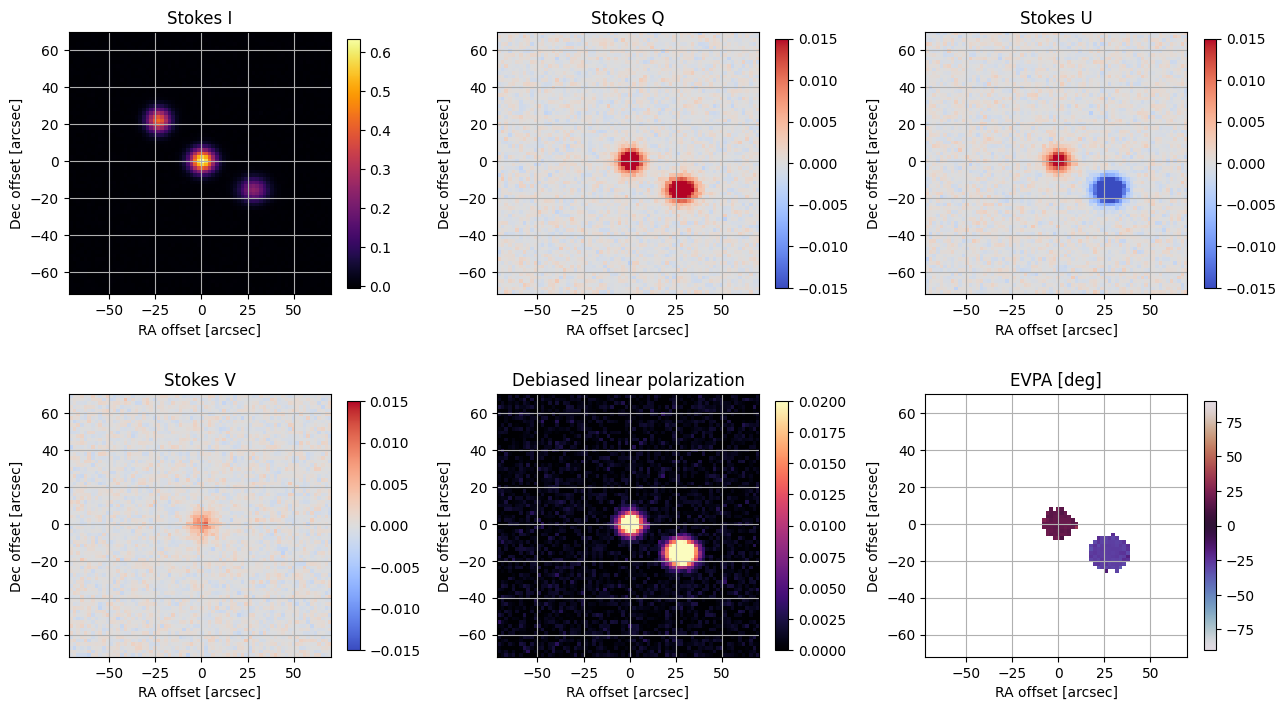

In [3]:
extent = [coords[0], coords[-1], coords[0], coords[-1]]
fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.4))

panels = [
    (ref_i, "Stokes I", "inferno", None, None),
    (ref_q, "Stokes Q", "coolwarm", -0.015, 0.015),
    (ref_u, "Stokes U", "coolwarm", -0.015, 0.015),
    (ref_v, "Stokes V", "coolwarm", -0.015, 0.015),
    (p_debiased_ref, "Debiased linear polarization", "magma", 0.0, 0.020),
    (evpa_ref, "EVPA [deg]", "twilight", -90.0, 90.0),
]

for ax, (image, title, cmap, vmin, vmax) in zip(axes.ravel(), panels):
    im = ax.imshow(
        image,
        origin="lower",
        extent=extent,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.82)

plt.tight_layout()

core_i_ref = integrated["core"]["I"][ref_index]
core_p_ref = np.sqrt(
    integrated["core"]["Q"][ref_index] ** 2 + integrated["core"]["U"][ref_index] ** 2
)
core_v_ref = np.abs(integrated["core"]["V"][ref_index])
lobe_i_ref = integrated["polarized_lobe"]["I"][ref_index]
lobe_p_ref = np.sqrt(
    integrated["polarized_lobe"]["Q"][ref_index] ** 2
    + integrated["polarized_lobe"]["U"][ref_index] ** 2
)

print(f"core 的线偏振分数 ≈ {100.0 * core_p_ref / core_i_ref:.1f}%")
print(f"core 的圆偏振分数 ≈ {100.0 * core_v_ref / core_i_ref:.1f}%")
print(f"polarized_lobe 的线偏振分数 ≈ {100.0 * lobe_p_ref / lobe_i_ref:.1f}%")


这一步的重点不是“记住哪种颜色代表哪种偏振”，而是建立一个判断：**偏振分析从来都不只是再多画几张图，而是在同一个数据立方里追踪多个物理自由度。**


### 9.9.2 为什么线偏振强度需要 debias

由于 $P=\sqrt{Q^2+U^2}$ 永远不小于零，即使纯噪声区域里 `Q/U` 的期望值是零，直接算出来的 `P` 也会偏正。这个问题在弱偏振源附近尤其关键。

下面专门看离源背景区域，比较 raw `P` 和 debiased `P` 的分布。


离源区域 raw P 的中位数 ≈ 1.04 mJy/beam
离源区域 debiased P 的中位数 ≈ 0.52 mJy/beam


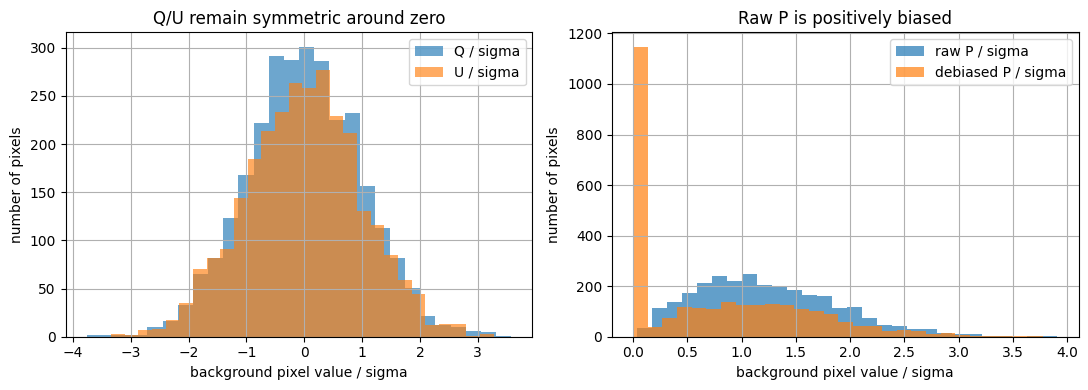

In [4]:
background_mask = radius_grid > 55.0

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

axes[0].hist(ref_q[background_mask] / noise_quv, bins=28, alpha=0.65, label="Q / sigma")
axes[0].hist(ref_u[background_mask] / noise_quv, bins=28, alpha=0.65, label="U / sigma")
axes[0].set_xlabel("background pixel value / sigma")
axes[0].set_ylabel("number of pixels")
axes[0].set_title("Q/U remain symmetric around zero")
axes[0].legend(loc="upper right")

axes[1].hist(p_raw_ref[background_mask] / noise_quv, bins=28, alpha=0.70, label="raw P / sigma")
axes[1].hist(
    p_debiased_ref[background_mask] / noise_quv,
    bins=28,
    alpha=0.70,
    label="debiased P / sigma",
)
axes[1].set_xlabel("background pixel value / sigma")
axes[1].set_ylabel("number of pixels")
axes[1].set_title("Raw P is positively biased")
axes[1].legend(loc="upper right")

plt.tight_layout()

print(f"离源区域 raw P 的中位数 ≈ {1e3 * np.median(p_raw_ref[background_mask]):.2f} mJy/beam")
print(
    f"离源区域 debiased P 的中位数 ≈ "
    f"{1e3 * np.median(p_debiased_ref[background_mask]):.2f} mJy/beam"
)


在真实数据里，这个步骤会直接影响：

- 弱偏振源是否被误判为探测到；
- 偏振分数 $m_L=P/I$ 是否被系统性高估；
- 后续的 `EVPA` 与 `RM` 分析是否建立在可靠像素之上。


### 9.9.3 leakage / D-term 为什么会制造“假偏振”

偏振校准里最经典的系统误差之一，就是把一部分强 Stokes `I` 信号泄漏进 `Q/U`。这类方向无关的一阶污染，常常用 `D-term` 来描述。

下面人为加入一个简化 leakage：

- `Q <- Q + 0.018 I`
- `U <- U - 0.012 I`

然后比较参考频率下的线偏振图像，以及一个本来不偏振的热点在校正前后的表观偏振分数。


非偏振热点在原始 Q/U 图中的表观线偏振分数 ≈ 0.03%
加入 leakage 后表观线偏振分数 ≈ 2.15%
做 leakage 校正后表观线偏振分数 ≈ 0.03%


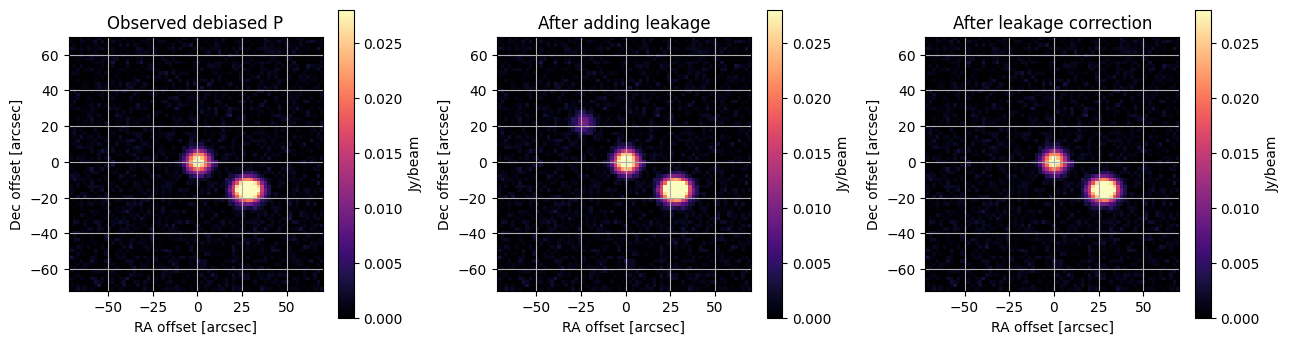

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.1))

for ax, image, title in [
    (axes[0], p_debiased_ref, "Observed debiased P"),
    (axes[1], p_leaky_ref, "After adding leakage"),
    (axes[2], p_corrected_ref, "After leakage correction"),
]:
    im = ax.imshow(
        image,
        origin="lower",
        extent=extent,
        cmap="magma",
        vmin=0.0,
        vmax=0.028,
    )
    ax.set_title(title)
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Jy/beam")

plt.tight_layout()

hotspot_i_ref = integrated["unpolarized_hotspot"]["I"][ref_index]
hotspot_p_ref = np.sqrt(
    integrated["unpolarized_hotspot"]["Q"][ref_index] ** 2
    + integrated["unpolarized_hotspot"]["U"][ref_index] ** 2
)
hotspot_p_leaky_ref = np.sqrt(
    integrated["unpolarized_hotspot"]["Q_leaky"][ref_index] ** 2
    + integrated["unpolarized_hotspot"]["U_leaky"][ref_index] ** 2
)
hotspot_p_corrected_ref = np.sqrt(
    integrated["unpolarized_hotspot"]["Q_corrected"][ref_index] ** 2
    + integrated["unpolarized_hotspot"]["U_corrected"][ref_index] ** 2
)

print(
    f"非偏振热点在原始 Q/U 图中的表观线偏振分数 ≈ "
    f"{100.0 * hotspot_p_ref / hotspot_i_ref:.2f}%"
)
print(
    f"加入 leakage 后表观线偏振分数 ≈ "
    f"{100.0 * hotspot_p_leaky_ref / hotspot_i_ref:.2f}%"
)
print(
    f"做 leakage 校正后表观线偏振分数 ≈ "
    f"{100.0 * hotspot_p_corrected_ref / hotspot_i_ref:.2f}%"
)


这正是偏振校准为什么不能被当成“细节修饰项”的原因。对于强源附近的弱偏振结构来说，哪怕只有百分之几的 leakage，也足以在科学解释上造成根本误导。


### 9.9.4 用 $\lambda^2$ 线性关系做一个最小 RM 拟合

在简单 Faraday screen 近似下，偏振角满足：

$$
\chi(\lambda^2) = \chi_0 + \mathrm{RM}\,\lambda^2 .
$$

这意味着只要你能在多个频率上稳定测到 `Q/U`，就可以把偏振角展开到 $\lambda^2$ 空间里做直线拟合。下面分别看：

- 一个弱偏振 core：加入 leakage 后，`RM` 会被明显拉偏；
- 一个高偏振 lobe：在这个简化例子里，`RM` 可以被较稳定地恢复出来。


core 真实 RM = +35.0 rad/m^2，观测估计 = +34.9，带 leakage = +37.4，校正后 = +34.9
polarized_lobe 真实 RM = -120.0 rad/m^2，观测估计 = -120.0


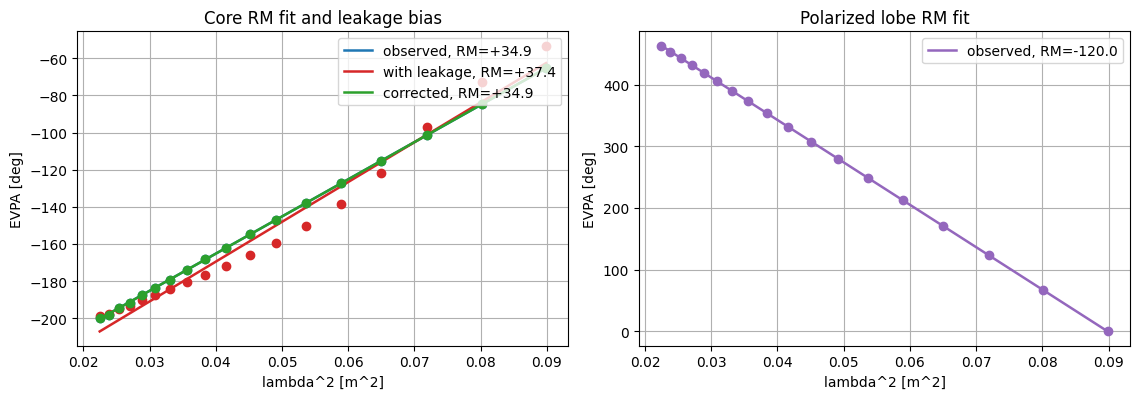

In [6]:
core_fit_obs = fit_rotation_measure(
    lambda2,
    integrated["core"]["Q"],
    integrated["core"]["U"],
    min_p=0.003,
)
core_fit_leaky = fit_rotation_measure(
    lambda2,
    integrated["core"]["Q_leaky"],
    integrated["core"]["U_leaky"],
    min_p=0.003,
)
core_fit_corrected = fit_rotation_measure(
    lambda2,
    integrated["core"]["Q_corrected"],
    integrated["core"]["U_corrected"],
    min_p=0.003,
)
lobe_fit_obs = fit_rotation_measure(
    lambda2,
    integrated["polarized_lobe"]["Q"],
    integrated["polarized_lobe"]["U"],
    min_p=0.003,
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))

for chi, valid, model, label, color in [
    (core_fit_obs[2], core_fit_obs[3], core_fit_obs[4], f"observed, RM={core_fit_obs[1]:+.1f}", "tab:blue"),
    (core_fit_leaky[2], core_fit_leaky[3], core_fit_leaky[4], f"with leakage, RM={core_fit_leaky[1]:+.1f}", "tab:red"),
    (core_fit_corrected[2], core_fit_corrected[3], core_fit_corrected[4], f"corrected, RM={core_fit_corrected[1]:+.1f}", "tab:green"),
]:
    axes[0].plot(lambda2[valid], np.rad2deg(chi[valid]), "o", color=color)
    axes[0].plot(lambda2, np.rad2deg(model), color=color, lw=1.8, label=label)

axes[0].set_xlabel("lambda^2 [m^2]")
axes[0].set_ylabel("EVPA [deg]")
axes[0].set_title("Core RM fit and leakage bias")
axes[0].legend(loc="upper right")

axes[1].plot(
    lambda2[lobe_fit_obs[3]],
    np.rad2deg(lobe_fit_obs[2][lobe_fit_obs[3]]),
    "o",
    color="tab:purple",
)
axes[1].plot(
    lambda2,
    np.rad2deg(lobe_fit_obs[4]),
    color="tab:purple",
    lw=1.8,
    label=f"observed, RM={lobe_fit_obs[1]:+.1f}",
)
axes[1].set_xlabel("lambda^2 [m^2]")
axes[1].set_ylabel("EVPA [deg]")
axes[1].set_title("Polarized lobe RM fit")
axes[1].legend(loc="upper right")

plt.tight_layout()

print(
    f"core 真实 RM = +35.0 rad/m^2，"
    f"观测估计 = {core_fit_obs[1]:+.1f}，"
    f"带 leakage = {core_fit_leaky[1]:+.1f}，"
    f"校正后 = {core_fit_corrected[1]:+.1f}"
)
print(
    f"polarized_lobe 真实 RM = -120.0 rad/m^2，"
    f"观测估计 = {lobe_fit_obs[1]:+.1f}"
)


这里必须强调一个专业边界：这个例子只对应“单一 Faraday 分量、角度随 $\lambda^2$ 近似线性”的最简情形。若存在多分量或 Faraday-thick 结构，真实工作里往往要进入 `RM synthesis` 和 Faraday depth 分析，而不是只做一条直线。


### 9.9.5 与真实软件流程的对应

若把这个教学实验映射回真实数据处理，通常会落到下面这些动作上：

- 先完成总强度校准，再进入交叉手 (`cross-hand`) 偏振校准；
- 处理 `XY phase` / `R-L phase`、cross-hand delay 和 `D-term`；
- 成 Stokes `I/Q/U/V` 图，再推导 debiased `P`、偏振角和偏振分数；
- 对宽频带数据，在足够信噪比和频率采样下做 `RM fit` 或 `RM synthesis`；
- 对最终物理解释，始终检查 leakage、带宽去极化、beam depolarization 和主波束偏振响应。

这个 notebook 仍然是入口级练习，但它已经把偏振数据处理中最常见的几个“坑”串到了同一条判断链上：**没有可靠的 `Q/U`、没有偏差控制、没有 leakage 校准，就谈不上可靠的偏振科学量。**
